# Customer Segmentation & Product Recommendation System

This project analyzes customer purchasing behavior using RFM analysis, customer segmentation, and product association rules to generate personalized product recommendations.

## 1. Import Libraries & Load Dataset

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/My Drive/Customer_Targeting_Recommendation_System"
OUTPUT_PATH = f"{PROJECT_PATH}/outputs"

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Project path:", PROJECT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project path: /content/drive/My Drive/Customer_Targeting_Recommendation_System


In [ ]:
import pandas as pd
df = pd.read_csv(
    f"{PROJECT_PATH}/data.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (541909, 8)


## 2. Data Understanding

In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 3. Data Quality Assessment

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [ ]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [ ]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
cancelled = df["InvoiceNo"].astype(str).str.startswith("C")
negative_qty = df["Quantity"] < 0

pd.crosstab(cancelled, negative_qty)

Quantity,False,True
InvoiceNo,,
False,531285,1336
True,0,9288


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [ ]:
df["CustomerID"].nunique()

4372

## 4. Data Cleaning & Preprocessing

In [ ]:
clean_df = df.copy()

In [ ]:
clean_df = clean_df.dropna(subset=["CustomerID"])

In [ ]:
clean_df = clean_df[clean_df["Quantity"] > 0]

In [ ]:
clean_df = clean_df[clean_df["UnitPrice"] > 0]

In [ ]:
clean_df = clean_df.drop_duplicates()

In [ ]:
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

In [ ]:
print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))
print("Unique customers:", clean_df["CustomerID"].nunique())
print("Duplicate rows:", clean_df.duplicated().sum())
print("Missing CustomerID:", clean_df["CustomerID"].isnull().sum())
print("Non-positive quantity:", (clean_df["Quantity"] <= 0).sum())
print("Non-positive price:", (clean_df["UnitPrice"] <= 0).sum())

Original rows: 541909
Clean rows: 392692
Rows removed: 149217
Unique customers: 4338
Duplicate rows: 0
Missing CustomerID: 0
Non-positive quantity: 0
Non-positive price: 0


## 5. Revenue Analysis

In [ ]:
non_product_codes = ["POST", "DOT", "M", "BANK CHARGES"]

clean_df = clean_df[
    ~clean_df["StockCode"].isin(non_product_codes)
].copy()

clean_df["Revenue"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

print(
    "Total Revenue:",
    round(clean_df["Revenue"].sum(), 2)
)

print(
    "Average Transaction Revenue:",
    round(clean_df["Revenue"].mean(), 2)
)

Total Revenue: 8743913.64
Average Transaction Revenue: 22.35


## 6. Customer-Level RFM Analysis

### 6.1 Customer-Level Metrics

In [ ]:
customer_revenue = clean_df.groupby("CustomerID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Items=("Quantity", "sum"),
    Total_Transactions=("InvoiceNo", "nunique"),
    Last_Purchase=("InvoiceDate", "max")
).reset_index()

customer_revenue.head()

,CustomerID,Total_Revenue,Total_Items,Total_Transactions,Last_Purchase
0,12346.0,77183.60,74215,1,2011-01-18 10:01:00
1,12347.0,4310.00,2458,7,2011-12-07 15:52:00
2,12348.0,1437.24,2332,4,2011-09-25 13:13:00
3,12349.0,1457.55,630,1,2011-11-21 09:51:00
4,12350.0,294.40,196,1,2011-02-02 16:01:00


### 6.2 Recency Analysis

In [ ]:

reference_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_revenue["Last_Purchase"] = pd.to_datetime(customer_revenue["Last_Purchase"])
customer_revenue["Recency_Days"] = (
    reference_date - customer_revenue["Last_Purchase"]
).dt.days

customer_revenue.head()

,CustomerID,Total_Revenue,Total_Items,Total_Transactions,Last_Purchase,Recency_Days
0,12346.0,77183.60,74215,1,2011-01-18 10:01:00,326
1,12347.0,4310.00,2458,7,2011-12-07 15:52:00,2
2,12348.0,1437.24,2332,4,2011-09-25 13:13:00,75
3,12349.0,1457.55,630,1,2011-11-21 09:51:00,19
4,12350.0,294.40,196,1,2011-02-02 16:01:00,310


### 6.3 Frequency & Monetary Analysis

In [ ]:
import numpy as np

customer_revenue["Frequency_Log"] = np.log1p(
    customer_revenue["Total_Transactions"]
)

In [ ]:
customer_revenue["Monetary_Log"] = np.log1p(
    customer_revenue["Total_Revenue"]
)

### 6.4 RFM Scoring

In [ ]:
customer_revenue["R_Score"] = pd.qcut(
    customer_revenue["Recency_Days"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [ ]:
customer_revenue["F_Score"] = pd.qcut(
    customer_revenue["Total_Transactions"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
customer_revenue["M_Score"] = pd.qcut(
    customer_revenue["Total_Revenue"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

## 7. Customer Value Scoring

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

customer_revenue["Recency_Norm"] = (
    1 - MinMaxScaler().fit_transform(
        customer_revenue[["Recency_Days"]]
    ).flatten()
)

In [ ]:
scaler = MinMaxScaler()

customer_revenue[
    ["Frequency_Norm", "Monetary_Norm"]
] = scaler.fit_transform(
    customer_revenue[
        ["Frequency_Log", "Monetary_Log"]
    ]
)

### 7.1 Customer Value Score

In [ ]:
customer_revenue["Customer_Value_Score"] = (
    customer_revenue["Recency_Norm"] * 0.40
    + customer_revenue["Frequency_Norm"] * 0.30
    + customer_revenue["Monetary_Norm"] * 0.30
)

In [ ]:
customer_revenue["Customer_Rank"] = (
    customer_revenue["Customer_Value_Score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

In [ ]:
top_customers = customer_revenue.sort_values(
    "Customer_Rank"
).head(20)

top_customers[
    [
        "CustomerID",
        "Recency_Days",
        "Total_Transactions",
        "Total_Revenue",
        "R_Score",
        "F_Score",
        "M_Score",
        "Customer_Value_Score",
        "Customer_Rank"
    ]
]

,CustomerID,Recency_Days,Total_Transactions,Total_Revenue,R_Score,F_Score,M_Score,Customer_Value_Score,Customer_Rank
1879,14911.0,1,199,140336.83,5,5,5,0.978989,1
326,12748.0,1,206,31650.78,5,5,5,0.940529,2
1689,14646.0,2,72,279138.02,5,5,5,0.931534,3
4197,18102.0,1,60,259657.30,5,5,5,0.919018,4
4007,17841.0,2,124,40495.99,5,5,5,0.913573,5
562,13089.0,3,97,58762.08,5,5,5,0.906936,6
2176,15311.0,1,91,60632.75,5,5,5,0.905852,7
3725,17450.0,8,46,194390.79,5,5,5,0.886744,8
1333,14156.0,10,55,117210.08,5,5,5,0.882107,9
996,13694.0,4,50,65039.62,5,5,5,0.866404,10


## 8. Customer Segmentation

In [ ]:
def assign_segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "VIP / Loyal"

    elif row["R_Score"] <= 2 and row["M_Score"] >= 4:
        return "High Value - Win Back"

    elif row["Customer_Value_Score"] >= high_value_threshold:
        return "High Potential"

    elif row["R_Score"] >= 4 and row["F_Score"] >= 3:
        return "Active - Cross Sell"

    else:
        return "Nurture"

In [ ]:
high_value_threshold = customer_revenue["Customer_Value_Score"].quantile(0.75)

customer_revenue["Customer_Segment"] = customer_revenue.apply(
    assign_segment,
    axis=1
)

In [ ]:
customer_revenue["Customer_Segment"].value_counts()

,count
Customer_Segment,
Nurture,2435
VIP / Loyal,943
Active - Cross Sell,422
High Value - Win Back,347
High Potential,187


## 9. Segment-Level Business Insights

In [ ]:
segment_summary = customer_revenue.groupby("Customer_Segment").agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Transactions=("Total_Transactions", "mean"),
    Avg_Recency=("Recency_Days", "mean")
).reset_index()

segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"] / len(customer_revenue) * 100
)

segment_summary

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Customer_Percentage
0,Active - Cross Sell,422,272075.160,644.727867,2.739336,16.445498,9.736964
1,High Potential,187,778631.190,4163.803155,6.983957,34.042781,4.314721
2,High Value - Win Back,347,839201.211,2418.447294,3.720461,143.893372,8.006461
3,Nurture,2435,1189161.292,488.361927,1.714579,134.175359,56.183664
4,VIP / Loyal,943,5664844.790,6007.258526,11.110286,12.535525,21.758191


In [ ]:
segment_summary["Revenue_Percentage"] = (
    segment_summary["Total_Revenue"] /
    segment_summary["Total_Revenue"].sum() * 100
)

segment_summary

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Customer_Percentage,Revenue_Percentage
0,Active - Cross Sell,422,272075.160,644.727867,2.739336,16.445498,9.736964,3.111595
1,High Potential,187,778631.190,4163.803155,6.983957,34.042781,4.314721,8.904836
2,High Value - Win Back,347,839201.211,2418.447294,3.720461,143.893372,8.006461,9.597547
3,Nurture,2435,1189161.292,488.361927,1.714579,134.175359,56.183664,13.599875
4,VIP / Loyal,943,5664844.790,6007.258526,11.110286,12.535525,21.758191,64.786147


In [ ]:
top_customers_by_segment = (
    customer_revenue
    .sort_values("Customer_Value_Score", ascending=False)
    .groupby("Customer_Segment")
    .head(10)
)

top_customers_by_segment[
    [
        "CustomerID",
        "Customer_Segment",
        "Recency_Days",
        "Total_Transactions",
        "Total_Revenue",
        "Customer_Value_Score",
        "Customer_Rank"
    ]
]

,CustomerID,Customer_Segment,Recency_Days,Total_Transactions,Total_Revenue,Customer_Value_Score,Customer_Rank
1879,14911.0,VIP / Loyal,1,199,140336.83,0.978989,1
326,12748.0,VIP / Loyal,1,206,31650.78,0.940529,2
1689,14646.0,VIP / Loyal,2,72,279138.02,0.931534,3
4197,18102.0,VIP / Loyal,1,60,259657.30,0.919018,4
4007,17841.0,VIP / Loyal,2,124,40495.99,0.913573,5
562,13089.0,VIP / Loyal,3,97,58762.08,0.906936,6
2176,15311.0,VIP / Loyal,1,91,60632.75,0.905852,7
3725,17450.0,VIP / Loyal,8,46,194390.79,0.886744,8
1333,14156.0,VIP / Loyal,10,55,117210.08,0.882107,9
996,13694.0,VIP / Loyal,4,50,65039.62,0.866404,10


In [ ]:
segment_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Customer_Percentage,Revenue_Percentage
4,VIP / Loyal,943,5664844.790,6007.258526,11.110286,12.535525,21.758191,64.786147
3,Nurture,2435,1189161.292,488.361927,1.714579,134.175359,56.183664,13.599875
2,High Value - Win Back,347,839201.211,2418.447294,3.720461,143.893372,8.006461,9.597547
1,High Potential,187,778631.190,4163.803155,6.983957,34.042781,4.314721,8.904836
0,Active - Cross Sell,422,272075.160,644.727867,2.739336,16.445498,9.736964,3.111595


In [ ]:
segment_summary.sort_values(
    "Avg_Revenue",
    ascending=False
)

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Customer_Percentage,Revenue_Percentage
4,VIP / Loyal,943,5664844.790,6007.258526,11.110286,12.535525,21.758191,64.786147
1,High Potential,187,778631.190,4163.803155,6.983957,34.042781,4.314721,8.904836
2,High Value - Win Back,347,839201.211,2418.447294,3.720461,143.893372,8.006461,9.597547
0,Active - Cross Sell,422,272075.160,644.727867,2.739336,16.445498,9.736964,3.111595
3,Nurture,2435,1189161.292,488.361927,1.714579,134.175359,56.183664,13.599875


In [ ]:
segment_summary.sort_values(
    "Avg_Recency"
)

,Customer_Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Customer_Percentage,Revenue_Percentage
4,VIP / Loyal,943,5664844.790,6007.258526,11.110286,12.535525,21.758191,64.786147
0,Active - Cross Sell,422,272075.160,644.727867,2.739336,16.445498,9.736964,3.111595
1,High Potential,187,778631.190,4163.803155,6.983957,34.042781,4.314721,8.904836
3,Nurture,2435,1189161.292,488.361927,1.714579,134.175359,56.183664,13.599875
2,High Value - Win Back,347,839201.211,2418.447294,3.720461,143.893372,8.006461,9.597547


In [ ]:
segment_rfm = customer_revenue.groupby("Customer_Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency_Score=("R_Score", "mean"),
    Avg_Frequency_Score=("F_Score", "mean"),
    Avg_Monetary_Score=("M_Score", "mean"),
    Avg_Value_Score=("Customer_Value_Score", "mean")
).reset_index()

segment_rfm

,Customer_Segment,Customers,Avg_Recency_Score,Avg_Frequency_Score,Avg_Monetary_Score,Avg_Value_Score
0,Active - Cross Sell,422,4.402844,3.327014,2.713270,0.552373
1,High Potential,187,3.556150,4.524064,4.368984,0.617102
2,High Value - Win Back,347,1.737752,3.328530,4.291066,0.455321
3,Nurture,2435,2.278850,2.119918,2.126899,0.389706
4,VIP / Loyal,943,4.588547,4.703075,4.636267,0.665808


In [ ]:
segment_rfm.sort_values(
    "Avg_Value_Score",
    ascending=False
)

,Customer_Segment,Customers,Avg_Recency_Score,Avg_Frequency_Score,Avg_Monetary_Score,Avg_Value_Score
4,VIP / Loyal,943,4.588547,4.703075,4.636267,0.665808
1,High Potential,187,3.556150,4.524064,4.368984,0.617102
0,Active - Cross Sell,422,4.402844,3.327014,2.713270,0.552373
2,High Value - Win Back,347,1.737752,3.328530,4.291066,0.455321
3,Nurture,2435,2.278850,2.119918,2.126899,0.389706


In [ ]:
def recommend_action(segment):

    if segment == "VIP / Loyal":
        return "Retain & Reward"

    elif segment == "High Potential":
        return "Upsell & Loyalty Program"

    elif segment == "Active - Cross Sell":
        return "Cross-Sell Products"

    elif segment == "High Value - Win Back":
        return "Win-Back Campaign"

    elif segment == "Nurture":
        return "Re-Engagement / Nurture"

    else:
        return "Monitor Customer"

In [ ]:
customer_revenue["Recommended_Action"] = (
    customer_revenue["Customer_Segment"].apply(recommend_action)
)

In [ ]:
customer_revenue[
    [
        "CustomerID",
        "Customer_Segment",
        "Customer_Value_Score",
        "Recommended_Action"
    ]
].head(20)

,CustomerID,Customer_Segment,Customer_Value_Score,Recommended_Action
0,12346.0,High Value - Win Back,0.316356,Win-Back Campaign
1,12347.0,VIP / Loyal,0.674632,Retain & Reward
2,12348.0,High Value - Win Back,0.535967,Win-Back Campaign
3,12349.0,Nurture,0.537155,Re-Engagement / Nurture
4,12350.0,Nurture,0.181466,Re-Engagement / Nurture
5,12352.0,High Potential,0.607185,Upsell & Loyalty Program
6,12353.0,Nurture,0.262669,Re-Engagement / Nurture
7,12354.0,High Value - Win Back,0.300538,Win-Back Campaign
8,12355.0,Nurture,0.296538,Re-Engagement / Nurture
9,12356.0,High Potential,0.592279,Upsell & Loyalty Program


In [ ]:
customer_revenue["Recommended_Action"].value_counts()

,count
Recommended_Action,
Re-Engagement / Nurture,2435
Retain & Reward,943
Cross-Sell Products,422
Win-Back Campaign,347
Upsell & Loyalty Program,187


In [ ]:
def assign_priority(segment):

    if segment in ["VIP / Loyal", "High Potential", "High Value - Win Back"]:
        return "High"

    elif segment == "Active - Cross Sell":
        return "Medium"

    elif segment == "Nurture":
        return "Low"

    else:
        return "Monitor"

In [ ]:
customer_revenue["Priority"] = (
    customer_revenue["Customer_Segment"].apply(assign_priority)
)

In [ ]:
customer_revenue["Priority"].value_counts()

,count
Priority,
Low,2435
High,1477
Medium,422


In [ ]:
customer_revenue[
    [
        "CustomerID",
        "Customer_Segment",
        "Customer_Value_Score",
        "Customer_Rank",
        "Recommended_Action",
        "Priority"
    ]
].sort_values(
    "Customer_Rank"
).head(20)

,CustomerID,Customer_Segment,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
1879,14911.0,VIP / Loyal,0.978989,1,Retain & Reward,High
326,12748.0,VIP / Loyal,0.940529,2,Retain & Reward,High
1689,14646.0,VIP / Loyal,0.931534,3,Retain & Reward,High
4197,18102.0,VIP / Loyal,0.919018,4,Retain & Reward,High
4007,17841.0,VIP / Loyal,0.913573,5,Retain & Reward,High
562,13089.0,VIP / Loyal,0.906936,6,Retain & Reward,High
2176,15311.0,VIP / Loyal,0.905852,7,Retain & Reward,High
3725,17450.0,VIP / Loyal,0.886744,8,Retain & Reward,High
1333,14156.0,VIP / Loyal,0.882107,9,Retain & Reward,High
996,13694.0,VIP / Loyal,0.866404,10,Retain & Reward,High


In [ ]:
pd.crosstab(
    customer_revenue["Customer_Segment"],
    customer_revenue["Recommended_Action"]
)

Recommended_Action,Cross-Sell Products,Re-Engagement / Nurture,Retain & Reward,Upsell & Loyalty Program,Win-Back Campaign
Customer_Segment,,,,,
Active - Cross Sell,422,0,0,0,0
High Potential,0,0,0,187,0
High Value - Win Back,0,0,0,0,347
Nurture,0,2435,0,0,0
VIP / Loyal,0,0,943,0,0


In [ ]:
pd.crosstab(
    customer_revenue["Customer_Segment"],
    customer_revenue["Priority"]
)

Priority,High,Low,Medium
Customer_Segment,,,
Active - Cross Sell,0,0,422
High Potential,187,0,0
High Value - Win Back,347,0,0
Nurture,0,2435,0
VIP / Loyal,943,0,0


In [ ]:
final_summary = customer_revenue.groupby(
    ["Customer_Segment", "Recommended_Action", "Priority"]
).agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Avg_Value_Score=("Customer_Value_Score", "mean")
).reset_index()

final_summary

,Customer_Segment,Recommended_Action,Priority,Customers,Total_Revenue,Avg_Value_Score
0,Active - Cross Sell,Cross-Sell Products,Medium,422,272075.160,0.552373
1,High Potential,Upsell & Loyalty Program,High,187,778631.190,0.617102
2,High Value - Win Back,Win-Back Campaign,High,347,839201.211,0.455321
3,Nurture,Re-Engagement / Nurture,Low,2435,1189161.292,0.389706
4,VIP / Loyal,Retain & Reward,High,943,5664844.790,0.665808


### 9.1 Customer Segment Distribution

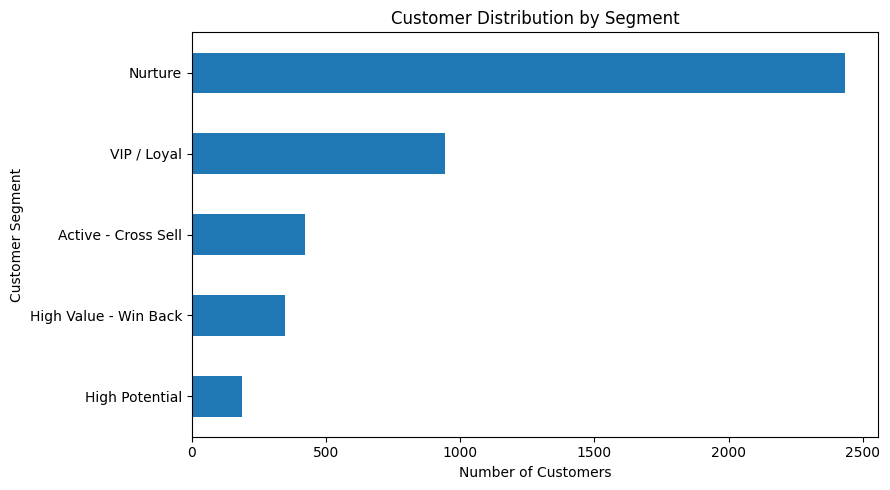

In [ ]:
import matplotlib.pyplot as plt

segment_counts = (
    customer_revenue["Customer_Segment"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
segment_counts.plot(kind="barh")

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

### 9.2 Segment Revenue Contribution

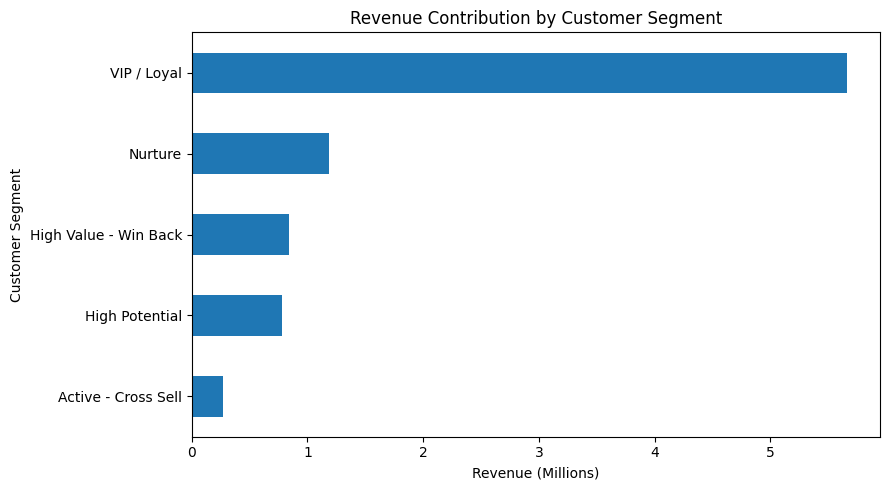

In [ ]:
revenue_by_segment_m = (
    customer_revenue.groupby("Customer_Segment")["Total_Revenue"]
    .sum()
    .sort_values(ascending=True) / 1_000_000
)

plt.figure(figsize=(9, 5))
revenue_by_segment_m.plot(kind="barh")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue (Millions)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

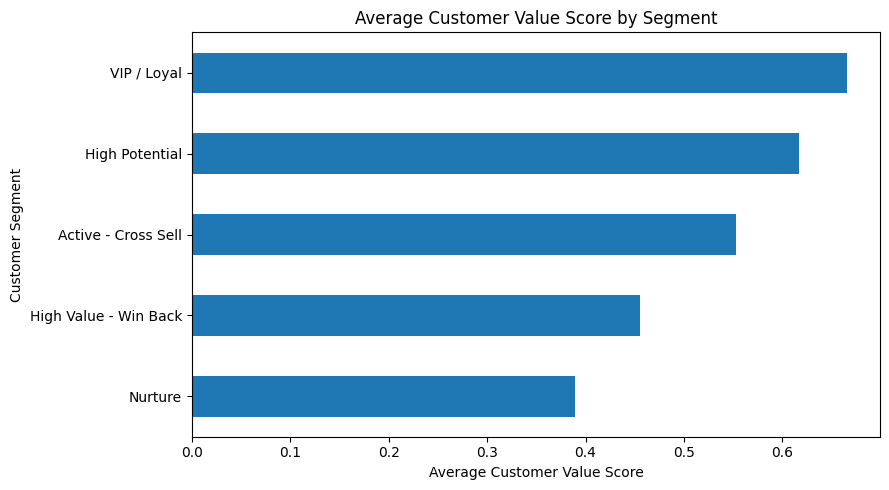

In [ ]:
avg_value = (
    customer_revenue.groupby("Customer_Segment")["Customer_Value_Score"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
avg_value.plot(kind="barh")

plt.title("Average Customer Value Score by Segment")
plt.xlabel("Average Customer Value Score")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

In [ ]:
final_business_summary = customer_revenue.groupby(
    ["Customer_Segment", "Recommended_Action", "Priority"]
).agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Transactions=("Total_Transactions", "mean"),
    Avg_Recency=("Recency_Days", "mean"),
    Avg_Value_Score=("Customer_Value_Score", "mean")
).reset_index()

final_business_summary

,Customer_Segment,Recommended_Action,Priority,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Avg_Value_Score
0,Active - Cross Sell,Cross-Sell Products,Medium,422,272075.160,644.727867,2.739336,16.445498,0.552373
1,High Potential,Upsell & Loyalty Program,High,187,778631.190,4163.803155,6.983957,34.042781,0.617102
2,High Value - Win Back,Win-Back Campaign,High,347,839201.211,2418.447294,3.720461,143.893372,0.455321
3,Nurture,Re-Engagement / Nurture,Low,2435,1189161.292,488.361927,1.714579,134.175359,0.389706
4,VIP / Loyal,Retain & Reward,High,943,5664844.790,6007.258526,11.110286,12.535525,0.665808


In [ ]:
final_business_summary["Revenue_Percentage"] = (
    final_business_summary["Total_Revenue"]
    / final_business_summary["Total_Revenue"].sum()
    * 100
)

final_business_summary

,Customer_Segment,Recommended_Action,Priority,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Avg_Value_Score,Revenue_Percentage
0,Active - Cross Sell,Cross-Sell Products,Medium,422,272075.160,644.727867,2.739336,16.445498,0.552373,3.111595
1,High Potential,Upsell & Loyalty Program,High,187,778631.190,4163.803155,6.983957,34.042781,0.617102,8.904836
2,High Value - Win Back,Win-Back Campaign,High,347,839201.211,2418.447294,3.720461,143.893372,0.455321,9.597547
3,Nurture,Re-Engagement / Nurture,Low,2435,1189161.292,488.361927,1.714579,134.175359,0.389706,13.599875
4,VIP / Loyal,Retain & Reward,High,943,5664844.790,6007.258526,11.110286,12.535525,0.665808,64.786147


In [ ]:
final_business_summary["Customer_Percentage"] = (
    final_business_summary["Customers"]
    / final_business_summary["Customers"].sum()
    * 100
)

final_business_summary

,Customer_Segment,Recommended_Action,Priority,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Avg_Value_Score,Revenue_Percentage,Customer_Percentage
0,Active - Cross Sell,Cross-Sell Products,Medium,422,272075.160,644.727867,2.739336,16.445498,0.552373,3.111595,9.736964
1,High Potential,Upsell & Loyalty Program,High,187,778631.190,4163.803155,6.983957,34.042781,0.617102,8.904836,4.314721
2,High Value - Win Back,Win-Back Campaign,High,347,839201.211,2418.447294,3.720461,143.893372,0.455321,9.597547,8.006461
3,Nurture,Re-Engagement / Nurture,Low,2435,1189161.292,488.361927,1.714579,134.175359,0.389706,13.599875,56.183664
4,VIP / Loyal,Retain & Reward,High,943,5664844.790,6007.258526,11.110286,12.535525,0.665808,64.786147,21.758191


In [ ]:
top_customers = customer_revenue[
    [
        "CustomerID",
        "Customer_Segment",
        "Total_Revenue",
        "Total_Transactions",
        "Recency_Days",
        "Customer_Value_Score",
        "Customer_Rank",
        "Recommended_Action",
        "Priority"
    ]
].sort_values(
    "Customer_Value_Score",
    ascending=False
).head(20)

top_customers

,CustomerID,Customer_Segment,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
1879,14911.0,VIP / Loyal,140336.83,199,1,0.978989,1,Retain & Reward,High
326,12748.0,VIP / Loyal,31650.78,206,1,0.940529,2,Retain & Reward,High
1689,14646.0,VIP / Loyal,279138.02,72,2,0.931534,3,Retain & Reward,High
4197,18102.0,VIP / Loyal,259657.30,60,1,0.919018,4,Retain & Reward,High
4007,17841.0,VIP / Loyal,40495.99,124,2,0.913573,5,Retain & Reward,High
562,13089.0,VIP / Loyal,58762.08,97,3,0.906936,6,Retain & Reward,High
2176,15311.0,VIP / Loyal,60632.75,91,1,0.905852,7,Retain & Reward,High
3725,17450.0,VIP / Loyal,194390.79,46,8,0.886744,8,Retain & Reward,High
1333,14156.0,VIP / Loyal,117210.08,55,10,0.882107,9,Retain & Reward,High
996,13694.0,VIP / Loyal,65039.62,50,4,0.866404,10,Retain & Reward,High


In [ ]:
high_potential = customer_revenue[
    customer_revenue["Customer_Segment"] == "High Potential"
].sort_values(
    "Customer_Value_Score",
    ascending=False
)

high_potential[
    [
        "CustomerID",
        "Total_Revenue",
        "Total_Transactions",
        "Recency_Days",
        "Customer_Value_Score",
        "Customer_Rank",
        "Recommended_Action",
        "Priority"
    ]
].head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
2700,16029.0,72708.09,62,39,0.845579,20,Upsell & Loyalty Program,High
2324,15513.0,14758.22,19,33,0.734258,122,Upsell & Loyalty Program,High
3209,16729.0,7202.01,21,38,0.715461,181,Upsell & Loyalty Program,High
3006,16446.0,168472.50,2,1,0.712424,195,Upsell & Loyalty Program,High
3299,16843.0,10196.57,16,43,0.702925,220,Upsell & Loyalty Program,High
69,12431.0,6314.95,15,36,0.693423,256,Upsell & Loyalty Program,High
269,12678.0,16481.46,10,42,0.688966,273,Upsell & Loyalty Program,High
3926,17719.0,5396.04,15,38,0.686983,281,Upsell & Loyalty Program,High
2479,15719.0,5028.42,13,33,0.681784,309,Upsell & Loyalty Program,High
737,13324.0,7121.95,10,36,0.672480,365,Upsell & Loyalty Program,High


In [ ]:
winback = customer_revenue[
    customer_revenue["Customer_Segment"] == "High Value - Win Back"
].sort_values(
    "Customer_Value_Score",
    ascending=False
)

winback[
    [
        "CustomerID",
        "Total_Revenue",
        "Total_Transactions",
        "Recency_Days",
        "Customer_Value_Score",
        "Customer_Rank",
        "Recommended_Action",
        "Priority"
    ]
].head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
3219,16745.0,7180.70,17,87,0.649857,518,Win-Back Campaign,High
3358,16928.0,2806.75,17,80,0.631707,659,Win-Back Campaign,High
2635,15939.0,6100.01,14,90,0.630396,671,Win-Back Campaign,High
3453,17061.0,5232.23,11,74,0.628934,684,Win-Back Campaign,High
2559,15827.0,1836.09,14,73,0.615836,814,Win-Back Campaign,High
2812,16180.0,10254.18,8,100,0.600829,976,Win-Back Campaign,High
1293,14101.0,5976.79,6,74,0.597716,1004,Win-Back Campaign,High
3994,17819.0,3704.87,7,72,0.595432,1027,Win-Back Campaign,High
2248,15410.0,3450.84,8,84,0.588240,1103,Win-Back Campaign,High
953,13631.0,3070.42,11,100,0.586494,1122,Win-Back Campaign,High


In [ ]:
winback_summary = customer_revenue[customer_revenue['Customer_Segment'] == 'High Value - Win Back'].agg({
    'CustomerID': 'count',
    'Total_Revenue': 'sum',
    'Total_Transactions': 'mean',
    'Recency_Days': 'mean',
    'Customer_Value_Score': 'mean'
})

winback_summary

,0
CustomerID,347.000000
Total_Revenue,839201.211000
Total_Transactions,3.720461
Recency_Days,143.893372
Customer_Value_Score,0.455321


In [ ]:
top_winback = (
    customer_revenue[customer_revenue['Customer_Segment'] == 'High Value - Win Back']
    .sort_values('Total_Revenue', ascending=False)
    .head(20)
)

top_winback[['CustomerID',
             'Total_Revenue',
             'Total_Transactions',
             'Recency_Days',
             'Customer_Value_Score',
             'Customer_Rank',
             'Recommended_Action',
             'Priority']]

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
0,12346.0,77183.60,1,326,0.316356,3580,Win-Back Campaign,High
2502,15749.0,44534.30,3,235,0.443739,2902,Win-Back Campaign,High
2011,15098.0,39916.50,3,182,0.497585,2208,Win-Back Campaign,High
50,12409.0,11072.67,3,79,0.573011,1291,Win-Back Campaign,High
2812,16180.0,10254.18,8,100,0.600829,976,Win-Back Campaign,High
196,12590.0,9341.26,1,211,0.381991,3294,Win-Back Campaign,High
566,13093.0,7832.47,8,276,0.404730,3183,Win-Back Campaign,High
73,12435.0,7829.89,2,80,0.543871,1652,Win-Back Campaign,High
485,12980.0,7374.90,9,158,0.536440,1729,Win-Back Campaign,High
3219,16745.0,7180.70,17,87,0.649857,518,Win-Back Campaign,High


### 9.3 Recommended Customer Actions

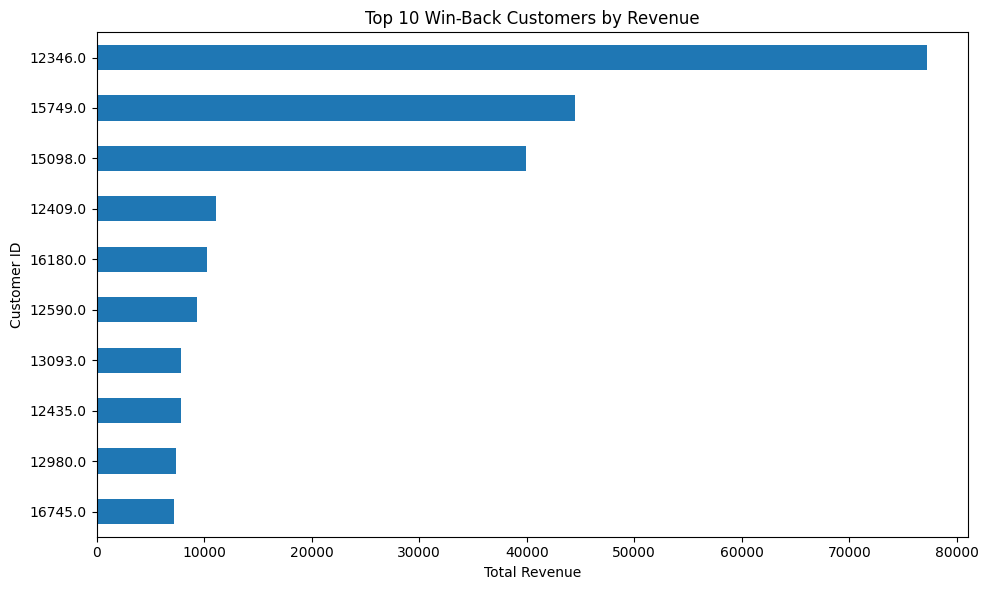

In [ ]:
import matplotlib.pyplot as plt

winback_revenue = (
    customer_revenue[customer_revenue['Customer_Segment'] == 'High Value - Win Back']
    .groupby('CustomerID')['Total_Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
winback_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Win-Back Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

In [ ]:
winback_customers = customer_revenue[customer_revenue['Customer_Segment'] == 'High Value - Win Back']

winback_customers[
    [
        'CustomerID',
        'Total_Revenue',
        'Total_Transactions',
        'Recency_Days',
        'Customer_Value_Score',
        'Customer_Rank',
        'Recommended_Action',
        'Priority'
    ]
].sort_values(
    by='Customer_Value_Score',
    ascending=False
).head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
3219,16745.0,7180.70,17,87,0.649857,518,Win-Back Campaign,High
3358,16928.0,2806.75,17,80,0.631707,659,Win-Back Campaign,High
2635,15939.0,6100.01,14,90,0.630396,671,Win-Back Campaign,High
3453,17061.0,5232.23,11,74,0.628934,684,Win-Back Campaign,High
2559,15827.0,1836.09,14,73,0.615836,814,Win-Back Campaign,High
2812,16180.0,10254.18,8,100,0.600829,976,Win-Back Campaign,High
1293,14101.0,5976.79,6,74,0.597716,1004,Win-Back Campaign,High
3994,17819.0,3704.87,7,72,0.595432,1027,Win-Back Campaign,High
2248,15410.0,3450.84,8,84,0.588240,1103,Win-Back Campaign,High
953,13631.0,3070.42,11,100,0.586494,1122,Win-Back Campaign,High


In [ ]:
winback_customers.sort_values(
    by=['Recency_Days', 'Customer_Value_Score'],
    ascending=[False, False]
)[[
    'CustomerID',
    'Total_Revenue',
    'Total_Transactions',
    'Recency_Days',
    'Customer_Value_Score',
    'Customer_Rank',
    'Recommended_Action',
    'Priority'
]].head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
4012,17850.0,5391.21,34,372,0.379396,3307,Win-Back Campaign,High
3227,16754.0,2002.40,1,372,0.167274,4146,Win-Back Campaign,High
2192,15332.0,1661.06,4,366,0.227854,3929,Win-Back Campaign,High
478,12967.0,1660.90,2,358,0.203400,4041,Win-Back Campaign,High
908,13564.0,1174.03,2,354,0.198219,4060,Win-Back Campaign,High
2878,16270.0,1141.24,1,353,0.172300,4133,Win-Back Campaign,High
2289,15464.0,1044.65,1,338,0.185972,4102,Win-Back Campaign,High
123,12501.0,2025.39,1,337,0.205119,4032,Win-Back Campaign,High
3692,17406.0,2184.42,3,333,0.256292,3821,Win-Back Campaign,High
2070,15171.0,1289.50,1,331,0.199226,4054,Win-Back Campaign,High


In [ ]:
active_cross_sell = customer_revenue[
    customer_revenue['Customer_Segment'] == 'Active - Cross Sell'
]

active_cross_sell.sort_values(
    by='Customer_Value_Score',
    ascending=False
)[[
    'CustomerID',
    'Total_Revenue',
    'Total_Transactions',
    'Recency_Days',
    'Customer_Value_Score',
    'Customer_Rank',
    'Recommended_Action',
    'Priority'
]].head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
1957,15031.0,653.19,4,4,0.590585,1086,Cross-Sell Products,Medium
4074,17929.0,843.00,4,11,0.590038,1090,Cross-Sell Products,Medium
2060,15156.0,961.49,3,1,0.589922,1092,Cross-Sell Products,Medium
1102,13838.0,674.82,4,6,0.589329,1093,Cross-Sell Products,Medium
1949,15022.0,852.39,4,12,0.589268,1094,Cross-Sell Products,Medium
252,12654.0,529.98,5,11,0.589166,1095,Cross-Sell Products,Medium
3091,16566.0,614.66,5,15,0.588919,1097,Cross-Sell Products,Medium
1641,14577.0,859.71,4,13,0.588429,1101,Cross-Sell Products,Medium
2361,15561.0,800.59,4,12,0.587557,1107,Cross-Sell Products,Medium
2034,15123.0,2199.31,2,7,0.587474,1108,Cross-Sell Products,Medium


In [ ]:
nurture = customer_revenue[
    customer_revenue['Customer_Segment'] == 'Nurture'
]

nurture.sort_values(
    by='Customer_Value_Score',
    ascending=False
)[[
    'CustomerID',
    'Total_Revenue',
    'Total_Transactions',
    'Recency_Days',
    'Customer_Value_Score',
    'Customer_Rank',
    'Recommended_Action',
    'Priority'
]].head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
1579,14498.0,1957.32,5,43,0.590505,1087,Re-Engagement / Nurture,Low
1023,13728.0,1016.14,6,37,0.589010,1096,Re-Engagement / Nurture,Low
393,12843.0,1702.26,8,66,0.588246,1102,Re-Engagement / Nurture,Low
2106,15220.0,1778.96,6,52,0.588212,1104,Re-Engagement / Nurture,Low
2124,15241.0,1756.44,8,67,0.588029,1105,Re-Engagement / Nurture,Low
1827,14842.0,2824.69,4,44,0.587660,1106,Re-Engagement / Nurture,Low
182,12576.0,1315.83,5,36,0.587170,1112,Re-Engagement / Nurture,Low
2735,16081.0,2799.42,5,56,0.586335,1123,Re-Engagement / Nurture,Low
2528,15786.0,4919.00,3,46,0.586237,1124,Re-Engagement / Nurture,Low
170,12560.0,1918.01,2,5,0.585882,1127,Re-Engagement / Nurture,Low


In [ ]:
high_potential = customer_revenue[
    customer_revenue['Customer_Segment'] == 'High Potential'
]

high_potential.sort_values(
    by='Customer_Value_Score',
    ascending=False
)[[
    'CustomerID',
    'Total_Revenue',
    'Total_Transactions',
    'Recency_Days',
    'Customer_Value_Score',
    'Customer_Rank',
    'Recommended_Action',
    'Priority'
]].head(20)

,CustomerID,Total_Revenue,Total_Transactions,Recency_Days,Customer_Value_Score,Customer_Rank,Recommended_Action,Priority
2700,16029.0,72708.09,62,39,0.845579,20,Upsell & Loyalty Program,High
2324,15513.0,14758.22,19,33,0.734258,122,Upsell & Loyalty Program,High
3209,16729.0,7202.01,21,38,0.715461,181,Upsell & Loyalty Program,High
3006,16446.0,168472.50,2,1,0.712424,195,Upsell & Loyalty Program,High
3299,16843.0,10196.57,16,43,0.702925,220,Upsell & Loyalty Program,High
69,12431.0,6314.95,15,36,0.693423,256,Upsell & Loyalty Program,High
269,12678.0,16481.46,10,42,0.688966,273,Upsell & Loyalty Program,High
3926,17719.0,5396.04,15,38,0.686983,281,Upsell & Loyalty Program,High
2479,15719.0,5028.42,13,33,0.681784,309,Upsell & Loyalty Program,High
737,13324.0,7121.95,10,36,0.672480,365,Upsell & Loyalty Program,High


In [ ]:
customer_revenue.groupby('Customer_Segment').agg(
    Customers=('CustomerID', 'count'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Avg_Revenue=('Total_Revenue', 'mean'),
    Avg_Transactions=('Total_Transactions', 'mean'),
    Avg_Recency=('Recency_Days', 'mean'),
    Avg_Value_Score=('Customer_Value_Score', 'mean')
).sort_values(
    by='Total_Revenue',
    ascending=False
)

,Customers,Total_Revenue,Avg_Revenue,Avg_Transactions,Avg_Recency,Avg_Value_Score
Customer_Segment,,,,,,
VIP / Loyal,943,5664844.790,6007.258526,11.110286,12.535525,0.665808
Nurture,2435,1189161.292,488.361927,1.714579,134.175359,0.389706
High Value - Win Back,347,839201.211,2418.447294,3.720461,143.893372,0.455321
High Potential,187,778631.190,4163.803155,6.983957,34.042781,0.617102
Active - Cross Sell,422,272075.160,644.727867,2.739336,16.445498,0.552373


In [ ]:
segment_revenue = customer_revenue.groupby('Customer_Segment')['Total_Revenue'].sum()

segment_revenue_pct = (
    segment_revenue / segment_revenue.sum() * 100
).sort_values(ascending=False)

segment_revenue_pct

,Total_Revenue
Customer_Segment,
VIP / Loyal,64.786147
Nurture,13.599875
High Value - Win Back,9.597547
High Potential,8.904836
Active - Cross Sell,3.111595


## 10. Product Recommendation System

In [ ]:
clean_transactions = df.copy()

# Remove duplicate rows
clean_transactions = clean_transactions.drop_duplicates()

# Convert date
clean_transactions['InvoiceDate'] = pd.to_datetime(
    clean_transactions['InvoiceDate']
)

# Keep only customers with CustomerID
clean_transactions = clean_transactions[
    clean_transactions['CustomerID'].notna()
]

# Keep valid purchases
clean_transactions = clean_transactions[
    (clean_transactions['Quantity'] > 0) &
    (clean_transactions['UnitPrice'] > 0)
]

# Remove cancelled invoices
clean_transactions = clean_transactions[
    ~clean_transactions['InvoiceNo'].astype(str).str.startswith('C')
]

clean_transactions.shape

(392692, 8)

### 10.1 Customer-Product Analysis

In [ ]:
customer_product = (
    clean_transactions[
        ['CustomerID', 'StockCode']
    ]
    .drop_duplicates()
)


### 10.2 Product Popularity

In [ ]:
product_popularity = (
    customer_product
    .groupby('StockCode')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)



In [ ]:
popular_products = product_popularity[
    product_popularity >= 50
].index

popular_customer_product = customer_product[
    customer_product['StockCode'].isin(popular_products)
]

popular_customer_product.shape

(232323, 2)

### 10.3 Co-Purchase Analysis

In [ ]:
from scipy.sparse import csr_matrix
import numpy as np

popular_products = product_popularity[
    product_popularity >= 50
].index

popular_customer_product = customer_product[
    customer_product['StockCode'].isin(popular_products)
]

customer_cat = popular_customer_product['CustomerID'].astype('category')
product_cat = popular_customer_product['StockCode'].astype('category')

X = csr_matrix(
    (
        np.ones(len(popular_customer_product)),
        (customer_cat.cat.codes, product_cat.cat.codes)
    ),
    shape=(
        len(customer_cat.cat.categories),
        len(product_cat.cat.categories)
    )
)

co_purchase = X.T @ X

co_purchase = co_purchase.tocoo()

mask = co_purchase.row < co_purchase.col

pairs = pd.DataFrame({
    'StockCode_A': product_cat.cat.categories[co_purchase.row[mask]],
    'StockCode_B': product_cat.cat.categories[co_purchase.col[mask]],
    'Customers_Bought_Both': co_purchase.data[mask].astype(int)
})

pairs = pairs.sort_values(
    'Customers_Bought_Both',
    ascending=False
)


## 11. Recommendation System Evaluation

In [ ]:
cutoff_date = clean_transactions['InvoiceDate'].quantile(0.80)

cutoff_date

Timestamp('2011-11-01 15:55:00')

### 11.1 Train-Test Split

In [ ]:
train_transactions = clean_transactions[
    clean_transactions['InvoiceDate'] < cutoff_date
].copy()

test_transactions = clean_transactions[
    clean_transactions['InvoiceDate'] >= cutoff_date
].copy()

print("Train shape:", train_transactions.shape)
print("Test shape:", test_transactions.shape)

Train shape: (314131, 8)
Test shape: (78561, 8)


In [ ]:
train_customer_product = (
    train_transactions[['CustomerID', 'StockCode']]
    .drop_duplicates()
)

print("Train customer-product pairs:", train_customer_product.shape)
print("Unique customers:", train_customer_product['CustomerID'].nunique())
print("Unique products:", train_customer_product['StockCode'].nunique())

Train customer-product pairs: (222344, 2)
Unique customers: 3985
Unique products: 3614


In [ ]:
train_product_popularity = (
    train_customer_product
    .groupby('StockCode')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)

train_popular_products = train_product_popularity[
    train_product_popularity >= 50
].index

train_popular_customer_product = train_customer_product[
    train_customer_product['StockCode'].isin(train_popular_products)
]

print("Popular products:", len(train_popular_products))
print("Filtered customer-product pairs:",
      train_popular_customer_product.shape)

Popular products: 1414
Filtered customer-product pairs: (185310, 2)


In [ ]:
from scipy.sparse import csr_matrix
import numpy as np
import pandas as pd

train_customer_cat = train_popular_customer_product['CustomerID'].astype('category')
train_product_cat = train_popular_customer_product['StockCode'].astype('category')

X_train = csr_matrix(
    (
        np.ones(len(train_popular_customer_product)),
        (
            train_customer_cat.cat.codes,
            train_product_cat.cat.codes
        )
    ),
    shape=(
        len(train_customer_cat.cat.categories),
        len(train_product_cat.cat.categories)
    )
)

train_co_purchase = X_train.T @ X_train
train_co_purchase = train_co_purchase.tocoo()

mask = train_co_purchase.row < train_co_purchase.col

train_pairs = pd.DataFrame({
    'StockCode_A': train_product_cat.cat.categories[
        train_co_purchase.row[mask]
    ],
    'StockCode_B': train_product_cat.cat.categories[
        train_co_purchase.col[mask]
    ],
    'Customers_Bought_Both': train_co_purchase.data[mask].astype(int)
})

train_pairs = train_pairs.sort_values(
    'Customers_Bought_Both',
    ascending=False
)

print("Number of product pairs:", len(train_pairs))
print(train_pairs.head(10))

Number of product pairs: 993598
       StockCode_A StockCode_B  Customers_Bought_Both
267977       22697       22699                    307
267984       22423       22699                    298
696          20725       20728                    289
785113       23298       47566                    282
164993       22469       22470                    281
139686       20725       22384                    281
266519       22423       22697                    279
138632       20725       22382                    276
664          20725       20727                    275
267244       22697       22698                    274


In [ ]:
train_total_customers = train_transactions['CustomerID'].nunique()

train_product_counts = (
    train_customer_product
    .groupby('StockCode')['CustomerID']
    .nunique()
)

train_pairs['Customers_A'] = train_pairs['StockCode_A'].map(
    train_product_counts
)

train_pairs['Customers_B'] = train_pairs['StockCode_B'].map(
    train_product_counts
)

train_pairs['Confidence_A_to_B'] = (
    train_pairs['Customers_Bought_Both'] /
    train_pairs['Customers_A']
)

train_pairs['Confidence_B_to_A'] = (
    train_pairs['Customers_Bought_Both'] /
    train_pairs['Customers_B']
)

train_pairs['Lift'] = (
    train_pairs['Customers_Bought_Both'] * train_total_customers /
    (train_pairs['Customers_A'] * train_pairs['Customers_B'])
)

print(train_pairs[
    [
        'StockCode_A',
        'StockCode_B',
        'Customers_Bought_Both',
        'Confidence_A_to_B',
        'Confidence_B_to_A',
        'Lift'
    ]
].head(10))

       StockCode_A StockCode_B  Customers_Bought_Both  Confidence_A_to_B  \
267977       22697       22699                    307           0.850416   
267984       22423       22699                    298           0.368356   
696          20725       20728                    289           0.576846   
785113       23298       47566                    282           0.530075   
164993       22469       22470                    281           0.557540   
139686       20725       22384                    281           0.560878   
266519       22423       22697                    279           0.344870   
138632       20725       22382                    276           0.550898   
664          20725       20727                    275           0.548902   
267244       22697       22698                    274           0.759003   

        Confidence_B_to_A       Lift  
267977           0.767500   8.472265  
267984           0.745000   3.669747  
696              0.646532   5.142578  
785113 

In [ ]:
train_strong_pairs = train_pairs[
    (train_pairs['Customers_Bought_Both'] >= 100) &
    (
        (train_pairs['Confidence_A_to_B'] >= 0.50) |
        (train_pairs['Confidence_B_to_A'] >= 0.50)
    ) &
    (train_pairs['Lift'] >= 3)
].copy()

print("Strong product pairs:", len(train_strong_pairs))

print(
    train_strong_pairs[
        [
            'StockCode_A',
            'StockCode_B',
            'Customers_Bought_Both',
            'Confidence_A_to_B',
            'Confidence_B_to_A',
            'Lift'
        ]
    ].head(10)
)

Strong product pairs: 482
       StockCode_A StockCode_B  Customers_Bought_Both  Confidence_A_to_B  \
267977       22697       22699                    307           0.850416   
267984       22423       22699                    298           0.368356   
696          20725       20728                    289           0.576846   
785113       23298       47566                    282           0.530075   
164993       22469       22470                    281           0.557540   
139686       20725       22384                    281           0.560878   
266519       22423       22697                    279           0.344870   
138632       20725       22382                    276           0.550898   
664          20725       20727                    275           0.548902   
267244       22697       22698                    274           0.759003   

        Confidence_B_to_A       Lift  
267977           0.767500   8.472265  
267984           0.745000   3.669747  
696              0.6

### 11.2 Association Rule Model

In [ ]:
rules_a_to_b = train_strong_pairs[
    [
        'StockCode_A',
        'StockCode_B',
        'Customers_Bought_Both',
        'Confidence_A_to_B',
        'Lift'
    ]
].copy()

rules_a_to_b = rules_a_to_b.rename(columns={
    'StockCode_A': 'Purchased_Product_Code',
    'StockCode_B': 'Recommended_Product_Code',
    'Confidence_A_to_B': 'Confidence'
})


rules_b_to_a = train_strong_pairs[
    [
        'StockCode_B',
        'StockCode_A',
        'Customers_Bought_Both',
        'Confidence_B_to_A',
        'Lift'
    ]
].copy()

rules_b_to_a = rules_b_to_a.rename(columns={
    'StockCode_B': 'Purchased_Product_Code',
    'StockCode_A': 'Recommended_Product_Code',
    'Confidence_B_to_A': 'Confidence'
})


train_recommendation_rules = pd.concat(
    [rules_a_to_b, rules_b_to_a],
    ignore_index=True
)

print("Directional rules:", len(train_recommendation_rules))

print(
    train_recommendation_rules.head(10)
)

Directional rules: 964
  Purchased_Product_Code Recommended_Product_Code  Customers_Bought_Both  \
0                  22697                    22699                    307   
1                  22423                    22699                    298   
2                  20725                    20728                    289   
3                  23298                    47566                    282   
4                  22469                    22470                    281   
5                  20725                    22384                    281   
6                  22423                    22697                    279   
7                  20725                    22382                    276   
8                  20725                    20727                    275   
9                  22697                    22698                    274   

   Confidence       Lift  
0    0.850416   8.472265  
1    0.368356   3.669747  
2    0.576846   5.142578  
3    0.530075   3.083722  
4    

In [ ]:
train_recommendation_rules['Recommendation_Score'] = (
    train_recommendation_rules['Confidence'] * 0.5    + (
        train_recommendation_rules['Lift'] /
        train_recommendation_rules['Lift'].max()
    ) * 0.3
    + (
        train_recommendation_rules['Customers_Bought_Both'] /
        train_recommendation_rules['Customers_Bought_Both'].max()
    ) * 0.2
)

train_recommendation_rules = train_recommendation_rules.sort_values(
    'Recommendation_Score',
    ascending=False
)

print(
    train_recommendation_rules[
        [
            'Purchased_Product_Code',
            'Recommended_Product_Code',
            'Customers_Bought_Both',
            'Confidence',
            'Lift',
            'Recommendation_Score'
        ]
    ].head(10)
)

    Purchased_Product_Code Recommended_Product_Code  Customers_Bought_Both  \
315                  22916                    22917                    118   
797                  22917                    22916                    118   
933                  22921                    22916                    103   
822                  22918                    22916                    115   
946                  22921                    22918                    102   
340                  22916                    22918                    115   
941                  22921                    22917                    102   
828                  22918                    22917                    114   
348                  22918                    22920                    114   
331                  22917                    22919                    116   

     Confidence       Lift  Recommendation_Score  
315    0.967213  31.083421              0.857050  
797    0.951613  31.083421             

In [ ]:
test_customer_products = (
    test_transactions[
        ['CustomerID', 'StockCode']
    ]
    .drop_duplicates()
)

print("Test customer-product pairs:", test_customer_products.shape)
print("Test customers:", test_customer_products['CustomerID'].nunique())
print("Test products:", test_customer_products['StockCode'].nunique())

Test customer-product pairs: (66496, 2)
Test customers: 1883
Test products: 2763


In [ ]:
test_purchase_dict = (
    test_customer_products
    .groupby('CustomerID')['StockCode']
    .apply(set)
    .to_dict()
)

print("Customers in test dictionary:", len(test_purchase_dict))



Customers in test dictionary: 1883


In [ ]:
def recommend_from_train(customer_id, top_n=5):

    # Products purchased by customer in training period
    purchased_products = set(
        train_transactions[
            train_transactions['CustomerID'] == customer_id
        ]['StockCode']
    )

    # Rules triggered by customer's purchased products
    recommendations = train_recommendation_rules[
        train_recommendation_rules['Purchased_Product_Code']
        .isin(purchased_products)
    ].copy()

    # Don't recommend products already purchased in training
    recommendations = recommendations[
        ~recommendations['Recommended_Product_Code']
        .isin(purchased_products)
    ]

    # Highest recommendation score first
    recommendations = recommendations.sort_values(
        'Recommendation_Score',
        ascending=False
    )

    # One recommendation per product
    recommendations = recommendations.drop_duplicates(
        'Recommended_Product_Code'
    )

    return recommendations[
        [
            'Purchased_Product_Code',
            'Recommended_Product_Code',
            'Confidence',
            'Lift',
            'Recommendation_Score'
        ]
    ].head(top_n)

### 11.3 Baseline Evaluation

In [ ]:
results = []

for customer_id, actual_products in test_purchase_dict.items():

    recommendations = recommend_from_train(
        customer_id,
        top_n=5
    )

    recommended_products = set(
        recommendations['Recommended_Product_Code']
    )

    hits = recommended_products.intersection(actual_products)

    hit = 1 if len(hits) > 0 else 0

    recall = len(hits) / len(actual_products)

    results.append({
        'CustomerID': customer_id,
        'Actual_Test_Products': len(actual_products),
        'Recommended_Products': len(recommended_products),
        'Hits': len(hits),
        'Hit@5': hit,
        'Recall@5': recall
    })

evaluation_results = pd.DataFrame(results)

print(evaluation_results.head())
print()
print("Customers evaluated:", len(evaluation_results))
print("Hit Rate@5:", evaluation_results['Hit@5'].mean())
print("Average Recall@5:", evaluation_results['Recall@5'].mean())

   CustomerID  Actual_Test_Products  Recommended_Products  Hits  Hit@5  \
0     12347.0                    11                     5     0      0   
1     12349.0                    73                     0     0      0   
2     12352.0                    15                     5     0      0   
3     12356.0                     2                     5     0      0   
4     12357.0                   131                     0     0      0   

   Recall@5  
0       0.0  
1       0.0  
2       0.0  
3       0.0  
4       0.0  

Customers evaluated: 1883
Hit Rate@5: 0.19437068507700478
Average Recall@5: 0.009786368139068502


In [ ]:
coverage_at_5 = (
    evaluation_results['Recommended_Products'] > 0
).mean()

print("Recommendation Coverage@5:", coverage_at_5)
print(
    "Customers receiving recommendations:",
    (evaluation_results['Recommended_Products'] > 0).sum()
)
print(
    "Customers receiving no recommendations:",
    (evaluation_results['Recommended_Products'] == 0).sum()
)

Recommendation Coverage@5: 0.7817312798725438
Customers receiving recommendations: 1472
Customers receiving no recommendations: 411


In [ ]:
covered_customers = evaluation_results[
    evaluation_results['Recommended_Products'] > 0
].copy()

covered_hit_rate = covered_customers['Hit@5'].mean()
covered_recall = covered_customers['Recall@5'].mean()

print("Covered customers:", len(covered_customers))
print("Hit Rate@5 among covered customers:", covered_hit_rate)
print("Recall@5 among covered customers:", covered_recall)

Covered customers: 1472
Hit Rate@5 among covered customers: 0.24864130434782608
Recall@5 among covered customers: 0.01251883913441983


In [ ]:
train_popular_product_ranking = (
    train_customer_product
    .groupby('StockCode')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)



### 11.4 Popularity Fallback

In [ ]:
def recommend_with_fallback(customer_id, top_n=5):

    # Customer ke training purchases
    purchased_products = set(
        train_transactions[
            train_transactions['CustomerID'] == customer_id
        ]['StockCode']
    )

    # Pehle normal association-rule recommendations
    recommendations = train_recommendation_rules[
        train_recommendation_rules['Purchased_Product_Code']
        .isin(purchased_products)
    ].copy()

    recommendations = recommendations[
        ~recommendations['Recommended_Product_Code']
        .isin(purchased_products)
    ]

    recommendations = recommendations.sort_values(
        'Recommendation_Score',
        ascending=False
    )

    recommendations = recommendations.drop_duplicates(
        'Recommended_Product_Code'
    ).head(top_n)

    # Agar 5 se kam recommendations hain,
    # popular products se fill karo
    if len(recommendations) < top_n:

        needed = top_n - len(recommendations)

        existing_recommendations = set(
            recommendations['Recommended_Product_Code']
        )

        fallback_products = [
            product
            for product in train_popular_product_ranking.index
            if product not in purchased_products
            and product not in existing_recommendations
        ][:needed]

        fallback_df = pd.DataFrame({
            'Purchased_Product_Code': [None] * len(fallback_products),
            'Recommended_Product_Code': fallback_products,
            'Confidence': [0.0] * len(fallback_products),
            'Lift': [0.0] * len(fallback_products),
            'Recommendation_Score': [0.0] * len(fallback_products)
        })

        recommendations = pd.concat(
            [recommendations, fallback_df],
            ignore_index=True
        )

    return recommendations.head(top_n)

In [ ]:
fallback_results = []

for customer_id, actual_products in test_purchase_dict.items():

    recommendations = recommend_with_fallback(
        customer_id,
        top_n=5
    )

    recommended_products = set(
        recommendations['Recommended_Product_Code']
    )

    hits = recommended_products.intersection(actual_products)

    hit = 1 if len(hits) > 0 else 0

    recall = len(hits) / len(actual_products)

    fallback_results.append({
        'CustomerID': customer_id,
        'Actual_Test_Products': len(actual_products),
        'Recommended_Products': len(recommended_products),
        'Hits': len(hits),
        'Hit@5': hit,
        'Recall@5': recall
    })

fallback_evaluation = pd.DataFrame(fallback_results)

print("Customers evaluated:", len(fallback_evaluation))
print(
    "Hit Rate@5:",
    fallback_evaluation['Hit@5'].mean()
)
print(
    "Average Recall@5:",
    fallback_evaluation['Recall@5'].mean()
)
print(
    "Recommendation Coverage@5:",
    (
        fallback_evaluation['Recommended_Products'] > 0
    ).mean()
)

Customers evaluated: 1883
Hit Rate@5: 0.250663834306957
Average Recall@5: 0.013265237420807721
Recommendation Coverage@5: 1.0


In [ ]:
product_details = (
    clean_transactions[
        ['StockCode', 'Description']
    ]
    .dropna()
    .drop_duplicates('StockCode')
)



## 12. Final Recommendation Examples

In [ ]:
product_name_map = (
    product_details
    .set_index('StockCode')['Description']
    .to_dict()
)

def readable_recommendations(customer_id, top_n=5):
    recommendations = recommend_with_fallback(
        customer_id,
        top_n=top_n
    ).copy()

    recommendations['Purchased_Product'] = (
        recommendations['Purchased_Product_Code'].map(product_name_map)
    )

    recommendations['Recommended_Product'] = (
        recommendations['Recommended_Product_Code'].map(product_name_map)
    )

    return recommendations[
        [
            'Purchased_Product',
            'Recommended_Product',
            'Confidence',
            'Lift',
            'Recommendation_Score'
        ]
    ]

### Example Customers

In [ ]:
print(readable_recommendations(14646.0, top_n=5))

              Purchased_Product            Recommended_Product  Confidence  \
128  POPPY'S PLAYHOUSE BEDROOM       POPPY'S PLAYHOUSE KITCHEN    0.841837   
962    COFFEE MUG APPLES DESIGN       COFFEE MUG PEARS  DESIGN    0.719424   
214  POPPY'S PLAYHOUSE BEDROOM   POPPY'S PLAYHOUSE LIVINGROOM     0.724490   
891     WATERING CAN PINK BUNNY     WATERING CAN BLUE ELEPHANT    0.696774   
720        RED DINER WALL CLOCK         IVORY DINER WALL CLOCK    0.676923   

          Lift  Recommendation_Score  
128  16.206374              0.683037  
962  24.295818              0.656668  
214  17.497526              0.621699  
891  17.573704              0.586418  
720  12.151074              0.540390  


In [ ]:
print(readable_recommendations(16029.0, top_n=5))

                    Purchased_Product                 Recommended_Product  \
487           LUNCH BAG PINK POLKADOT             LUNCH BAG RED RETROSPOT   
494           LUNCH BAG PINK POLKADOT                 LUNCH BAG CARS BLUE   
500           LUNCH BAG PINK POLKADOT             LUNCH BAG  BLACK SKULL.   
115        COOK WITH WINE METAL SIGN          GIN + TONIC DIET METAL SIGN   
187  PINK BLUE FELT CRAFT TRINKET BOX  PINK CREAM FELT CRAFT TRINKET BOX    

     Confidence      Lift  Recommendation_Score  
487    0.673861  5.359952              0.571132  
494    0.640288  5.708158              0.548547  
500    0.618705  5.870332              0.533440  
115    0.651341  8.768898              0.520085  
187    0.632479  9.511047              0.503402  


In [ ]:
print(readable_recommendations(12347.0, top_n=5))

                      Purchased_Product                  Recommended_Product  \
891             WATERING CAN PINK BUNNY           WATERING CAN BLUE ELEPHANT   
506         60 TEATIME FAIRY CAKE CASES      PACK OF 72 RETROSPOT CAKE CASES   
913   RED 3 PIECE RETROSPOT CUTLERY SET   GREEN 3 PIECE POLKADOT CUTLERY SET   
181              WOODLAND CHARLOTTE BAG          RED RETROSPOT CHARLOTTE BAG   
792  SET OF 60 VINTAGE LEAF CAKE CASES   SET OF 60 PANTRY DESIGN CAKE CASES    

     Confidence       Lift  Recommendation_Score  
891    0.696774  17.573704              0.586418  
506    0.659631   4.462866              0.535262  
913    0.583333  18.020026              0.532002  
181    0.677273   8.848957              0.520134  
792    0.657459   8.012148              0.482699  


## 13. Model Comparison

In [ ]:
baseline_hit = evaluation_results['Hit@5'].mean() * 100
baseline_recall = evaluation_results['Recall@5'].mean() * 100
baseline_coverage = (
    (evaluation_results['Recommended_Products'] > 0).mean() * 100
)

fallback_hit = fallback_evaluation['Hit@5'].mean() * 100
fallback_recall = fallback_evaluation['Recall@5'].mean() * 100
fallback_coverage = (
    (fallback_evaluation['Recommended_Products'] > 0).mean() * 100
)

comparison = pd.DataFrame({
    'Model': [
        'Baseline Association Rules',
        'Association + Popularity Fallback'
    ],
    'Hit Rate@5 (%)': [
        round(baseline_hit, 2),
        round(fallback_hit, 2)
    ],
    'Recall@5 (%)': [
        round(baseline_recall, 2),
        round(fallback_recall, 2)
    ],
    'Coverage@5 (%)': [
        round(baseline_coverage, 2),
        round(fallback_coverage, 2)
    ]
})

print(comparison)

                               Model  Hit Rate@5 (%)  Recall@5 (%)  \
0         Baseline Association Rules           19.44          0.98   
1  Association + Popularity Fallback           25.07          1.33   

   Coverage@5 (%)  
0           78.17  
1          100.00  


In [ ]:
final_model_summary = {
    'Model': 'Association + Popularity Fallback',
    'Hit Rate@5': round(fallback_hit, 2),
    'Recall@5': round(fallback_recall, 2),
    'Coverage@5': round(fallback_coverage, 2)
}

print("Final Recommendation Model")
print("---------------------------")

for key, value in final_model_summary.items():
    print(f"{key}: {value}")

Final Recommendation Model
---------------------------
Model: Association + Popularity Fallback
Hit Rate@5: 25.07
Recall@5: 1.33
Coverage@5: 100.0


## 14. Key Findings

- Customer value is highly concentrated among the VIP / Loyal segment.
- Nurture represents the largest customer group and provides a significant re-engagement opportunity.
- High Potential customers represent an opportunity for upselling and loyalty-focused actions.
- High Value - Win Back customers represent a revenue recovery opportunity.
- The Association + Popularity Fallback approach achieved 100% recommendation coverage in the evaluation set.

In [ ]:
comparison.to_csv(
    f"{OUTPUT_PATH}/model_comparison.csv",
    index=False
)

train_recommendation_rules.to_csv(
    f"{OUTPUT_PATH}/recommendation_rules.csv",
    index=False
)

print("Model comparison and recommendation rules saved.")

Model comparison and recommendation rules saved.


In [ ]:
# Generate final recommendations for selected customers

customer_ids = [14646.0, 16029.0, 12347.0]

final_recommendations = []

for customer_id in customer_ids:
    recs = readable_recommendations(customer_id, top_n=5).copy()
    recs.insert(0, 'CustomerID', customer_id)
    final_recommendations.append(recs)

final_recommendations = pd.concat(
    final_recommendations,
    ignore_index=True
)

final_recommendations.to_csv(
    f"{OUTPUT_PATH}/final_recommendations.csv",
    index=False
)

print("Final recommendations saved successfully!")
print(final_recommendations)

Final recommendations saved successfully!
    CustomerID                   Purchased_Product  \
0      14646.0          POPPY'S PLAYHOUSE BEDROOM    
1      14646.0            COFFEE MUG APPLES DESIGN   
2      14646.0          POPPY'S PLAYHOUSE BEDROOM    
3      14646.0             WATERING CAN PINK BUNNY   
4      14646.0                RED DINER WALL CLOCK   
5      16029.0             LUNCH BAG PINK POLKADOT   
6      16029.0             LUNCH BAG PINK POLKADOT   
7      16029.0             LUNCH BAG PINK POLKADOT   
8      16029.0          COOK WITH WINE METAL SIGN    
9      16029.0    PINK BLUE FELT CRAFT TRINKET BOX   
10     12347.0             WATERING CAN PINK BUNNY   
11     12347.0         60 TEATIME FAIRY CAKE CASES   
12     12347.0   RED 3 PIECE RETROSPOT CUTLERY SET   
13     12347.0              WOODLAND CHARLOTTE BAG   
14     12347.0  SET OF 60 VINTAGE LEAF CAKE CASES    

                    Recommended_Product  Confidence       Lift  \
0             POPPY'S PLAYH

## 15. Conclusion

This project combines customer segmentation with product recommendation analysis to move from understanding customer behavior to generating actionable recommendations.

The final recommendation approach combines product association rules with a popularity-based fallback, allowing recommendations to be generated for all evaluated customers.